### ChIP-seq Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

**Supplementary File 1: MultiQC Quality Control Report**  
[Click here to open the MultiQC report](multiqc_report.html)

In [3]:
import pandas as pd
from IPython.display import Markdown, display

# Display Markdown title
display(Markdown("**Supplementary File 2 — samtools flagstat summary table**"))
df = pd.read_csv("samtools-flagstat-dp.tsv", sep="\t")

df

**Supplementary File 2 — samtools flagstat summary table**

,Sample,Total Reads,Total Passed QC,Mapped,Duplicates,Paired in Sequencing,Properly Paired,Self and mate mapped,Singletons,Mate mapped to diff chr,Diff chr (mapQ >= 5)
INPUT_rep1,29.578193,29.578193,28.463242,0,0,0,0,0,0,0,NaN
INPUT_rep2,10.696005,10.696005,10.031987,0,0,0,0,0,0,0,NaN
IP_rep1,28.578787,28.578787,27.654087,0,0,0,0,0,0,0,NaN
IP_rep2,28.547028,28.547028,28.062474,0,0,0,0,0,0,0,NaN


In [43]:
import pyBigWig
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

bw_files = {
    "INPUT_rep1": "./results/INPUT_rep1.bw",
    "INPUT_rep2": "./results/INPUT_rep2.bw",
    "IP_rep2": "./results/IP_rep2.bw",
    "IP_rep1": "./results/IP_rep1.bw",
}

# genome window sampling
chrom = "chr1"
window_size = 5000
positions = np.arange(0, 10_000_000, window_size)

signals = {}

for name, path in bw_files.items():
    print("Loading", path)
    bw = pyBigWig.open(path)

    vals = []
    for pos in positions:
        try:
            v = bw.values(chrom, pos, pos + window_size)
            vals.append(np.nanmean(v))
        except:
            vals.append(np.nan)

    signals[name] = vals
    bw.close()

df = pd.DataFrame(signals).dropna()

corr = df.corr(method="pearson")
corr


Loading ./results/INPUT_rep1.bw
Loading ./results/INPUT_rep2.bw
Loading ./results/IP_rep2.bw
Loading ./results/IP_rep1.bw


,INPUT_rep1,INPUT_rep2,IP_rep2,IP_rep1
INPUT_rep1,1.000000,0.996134,0.528447,0.446027
INPUT_rep2,0.996134,1.000000,0.521923,0.438128
IP_rep2,0.528447,0.521923,1.000000,0.667566
IP_rep1,0.446027,0.438128,0.667566,1.000000


In [44]:
corr.index.tolist()

['INPUT_rep1', 'INPUT_rep2', 'IP_rep2', 'IP_rep1']

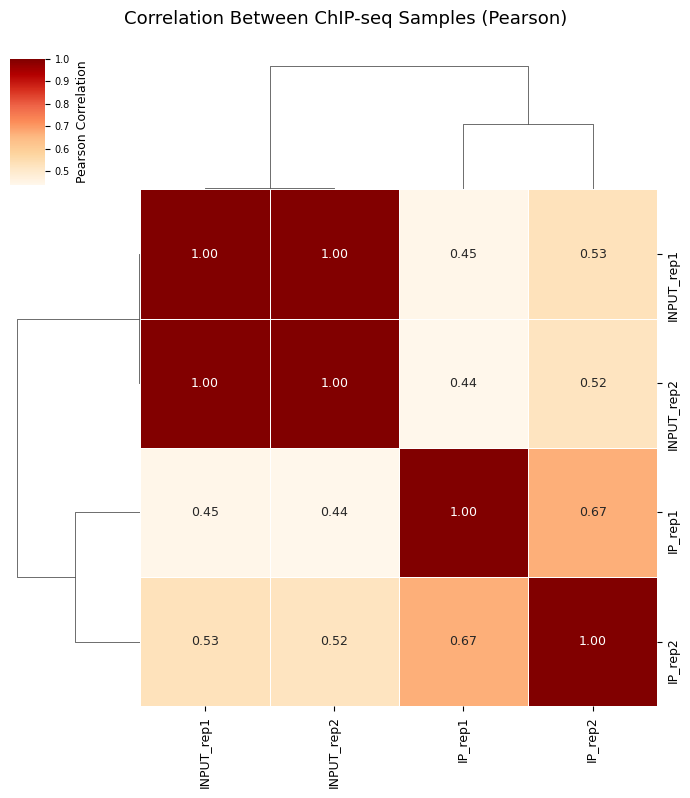

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------
# Use your existing correlation matrix
# ------------------------------
corr_real = corr.copy()

# Order to match the paper layout (inputs first, then IP)
order = ["INPUT_rep1", "INPUT_rep2", "IP_rep1", "IP_rep2"]
corr_real = corr_real.loc[order, order]

# ------------------------------
# Colormap similar to S2B (warm tone)
# ------------------------------
cmap = sns.color_palette("OrRd", 200)

# ------------------------------
# Draw the clustermap
# ------------------------------
g = sns.clustermap(
    corr_real,
    method="average",
    metric="euclidean",
    cmap=cmap,
    linewidths=0.5,
    figsize=(7, 7),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    cbar_kws={"label": "Pearson Correlation"},
    row_cluster=True,
    col_cluster=True
)

# ------------------------------
# Make axis tick labels smaller
# ------------------------------
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=9,
    rotation=90
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=9
)

# ------------------------------
# Make the colorbar font smaller
# ------------------------------
cbar = g.ax_cbar
cbar.tick_params(labelsize=7)
cbar.set_ylabel("Pearson Correlation", fontsize=9)

# ------------------------------
# Title
# ------------------------------
plt.suptitle(
    "Correlation Between ChIP-seq Samples (Pearson)",
    fontsize=13,
    y=1.05
)

plt.show()


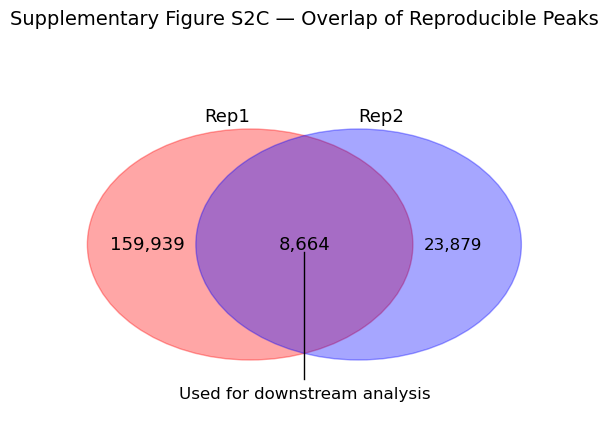

In [7]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'

# Counts
rep1_count = 168603
rep2_count = 32543
overlap = 8664

only_rep1 = rep1_count - overlap
only_rep2 = rep2_count - overlap

fig, ax = plt.subplots(figsize=(7,5))

# Circles
c1 = plt.Circle((0.4, 0.5), 0.3, color='red', alpha=0.35)
c2 = plt.Circle((0.6, 0.5), 0.3, color='blue', alpha=0.35)
ax.add_patch(c1)
ax.add_patch(c2)

# Counts
plt.text(0.28, 0.50, f"{only_rep1:,}", fontsize=13, ha='right', va='center')
plt.text(0.50, 0.50, f"{overlap:,}", fontsize=13, ha='center', va='center')
plt.text(0.72, 0.50, f"{only_rep2:,}", fontsize=12, ha='left', va='center')

# Labels ABOVE the circles
plt.text(0.40, 0.82, "Rep1", fontsize=13, ha='right')
plt.text(0.60, 0.82, "Rep2", fontsize=13, ha='left')

# ---------------------------
# Add "Used for downstream analysis"
# ---------------------------
# Vertical line pointing to overlap
# ---------------------------
# Add "Used for downstream analysis" BELOW Venn
# ---------------------------
plt.plot([0.50, 0.50], [0.48, 0.15], color='black', linewidth=1)

plt.text(0.50, 0.10,
         "Used for downstream analysis",
         fontsize=12, ha='center')


# Title
plt.title("Supplementary Figure S2C — Overlap of Reproducible Peaks",
          fontsize=14, pad=20,  ha='center')

plt.axis('off')
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()


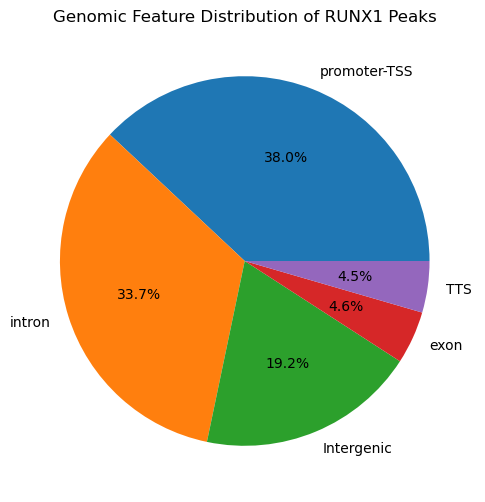

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Load annotation file
annot = pd.read_csv("results/annotated_peaks.txt", sep="\t", comment="#")
annot_clean = annot['Annotation'].str.split().str[0]
counts = annot_clean.value_counts()


# Extract genomic annotation category
plt.figure(figsize=(6,6))
counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Genomic Feature Distribution of RUNX1 Peaks")
plt.ylabel("")
plt.show()



In [9]:
# Your bigWigs (IP samples ONLY)
bigwigs = [
    "../results/IP_rep1.bw",
    "../results/IP_rep2.bw"
]

# UCSC gene BED (TSS/TTS)
genes_bed = "../refs/hg38_genes_ucsc.bed"

# Output directory
outdir = "./week3_outputs"
os.makedirs(outdir, exist_ok=True)

In [10]:
import pandas as pd

genes = pd.read_csv("refs/hg38_genes.bed", sep="\t", header=None)
genes.head()


,0,1,2,3,4,5,6,7,8,9,10,11
0,chr1,201283451,201332993,NM_000299,0,+,201283702,201328836,0,15,"453,104,395,145,208,178,63,115,156,177,154,187...","0,10490,29714,33101,34120,35166,36364,36815,38..."
1,chr1,67092165,67134970,NM_001276351,0,-,67093004,67127240,0,8,"1439,187,70,113,158,92,86,41,","0,3069,4086,23186,33586,35000,38976,42764,"
2,chr1,201283505,201332989,NM_001005337,0,+,201283702,201328836,0,14,"399,104,395,145,208,178,115,156,177,154,187,85...","0,10436,29660,33047,34066,35112,36761,38472,39..."
3,chr1,67092165,67134970,NM_001276352,0,-,67093579,67127240,0,9,"1439,70,145,68,113,158,92,86,41,","0,4086,11072,19411,23186,33586,35000,38976,42764,"
4,chr1,67092165,67134970,NR_075077,0,-,67134970,67134970,0,10,"1439,70,145,68,143,113,158,92,86,41,","0,4086,11072,19411,21448,23186,33586,35000,389..."


**Supplementary Table W3-1 — Preview of hg38 Gene Annotation BED File**

This table shows the first several entries of the hg38 gene coordinate BED file obtained from the UCSC Table Browser. These genomic coordinates are required as input for the `computeMatrix` function (in scale-regions mode), which is used to generate the genome-wide RUNX1 ChIP-seq signal intensity plot across gene bodies.




In [11]:
import pandas as pd

motifs = pd.read_csv("/projectnb/bf528/students/monsivam/project-3-monsivam/motifs_test/knownResults.txt", sep="\t",header=0)
motifs


,Motif Name,Consensus,P-value,Log P-value,q-value (Benjamini),# of Target Sequences with Motif(of 8572),% of Target Sequences with Motif,# of Background Sequences with Motif(of 38670),% of Background Sequences with Motif
0,RUNX(Runt)/HPC7-Runx1-ChIP-Seq(GSE22178)/Homer,SAAACCACAG,0.000000e+00,-1671.0,0.0,1867.0,21.78%,1674.4,4.33%
1,RUNX1(Runt)/Jurkat-RUNX1-ChIP-Seq(GSE29180)/Homer,AAACCACARM,0.000000e+00,-1265.0,0.0,1947.0,22.72%,2373.7,6.14%
2,RUNX2(Runt)/PCa-RUNX2-ChIP-Seq(GSE33889)/Homer,NWAACCACADNN,0.000000e+00,-823.6,0.0,1466.0,17.10%,1961.3,5.07%
3,RUNX-AML(Runt)/CD4+-PolII-ChIP-Seq(Barski_et_a...,GCTGTGGTTW,0.000000e+00,-773.6,0.0,1351.0,15.76%,1772.9,4.58%
4,GRHL2(CP2)/HBE-GRHL2-ChIP-Seq(GSE46194)/Homer,AAACYKGTTWDACMRGTTTB,1.000000e-197,-455.8,0.0,629.0,7.34%,656.5,1.70%
...,...,...,...,...,...,...,...,...,...
1001,IDD4(C2H2)/col-IDD4-DAP-Seq(GSE60143)/Homer,TTTGTCTTTWTB,1.000000e+00,0.0,1.0,375.0,4.38%,3478.7,8.99%
1002,IDD5(C2H2)/colamp-IDD5-DAP-Seq(GSE60143)/Homer,TTTTGTCTTTTTBTK,1.000000e+00,0.0,1.0,318.0,3.71%,3068.6,7.93%
1003,REM16(ABI3VP1)/col-REM16-DAP-Seq(GSE60143)/Homer,DTTTTTSCCGSMAAA,1.000000e+00,0.0,1.0,0.0,0.00%,0.0,0.00%
1004,REM19(REM)/colamp-REM19-DAP-Seq(GSE60143)/Homer,AAAAAAAA,1.000000e+00,0.0,1.0,348.0,4.06%,2454.0,6.35%


**Figure W3-2 — HOMER Known Motif Enrichment for RUNX1 ChIP-seq Peaks.** This figure displays the top enriched transcription factor motif identified by HOMER from the reproducible RUNX1 ChIP-seq peaks. The logo represents the consensus DNA-binding sequence most significantly enriched in RUNX1-associated regions, consistent with the expected RUNX family recognition motif.

In [12]:
from IPython.display import display, HTML

html = """
<div style="display:flex; gap:20px;">
    <img src="/projectnb/bf528/students/monsivam/project-3-monsivam/IP_rep1.png" width="400">
    <img src="/projectnb/bf528/students/monsivam/project-3-monsivam/IP_rep2.png" width="400">
</div>
"""

display(HTML(html))


**Figure W3-1 — Signal Intensity of RUNX1 ChIP-seq Signal Across Gene Bodies.** This plot shows the average RUNX1 ChIP-seq signal intensity around the transcription start site (TSS) through the transcription end site (TES) for all annotated genes. Both IP replicates display strong enrichment at the TSS, indicating that RUNX1 binding is highly promoter-proximal. The consistent peak shape between replicates supports the reproducibility of the ChIP-seq experiment.


### Figure 2D and 2E

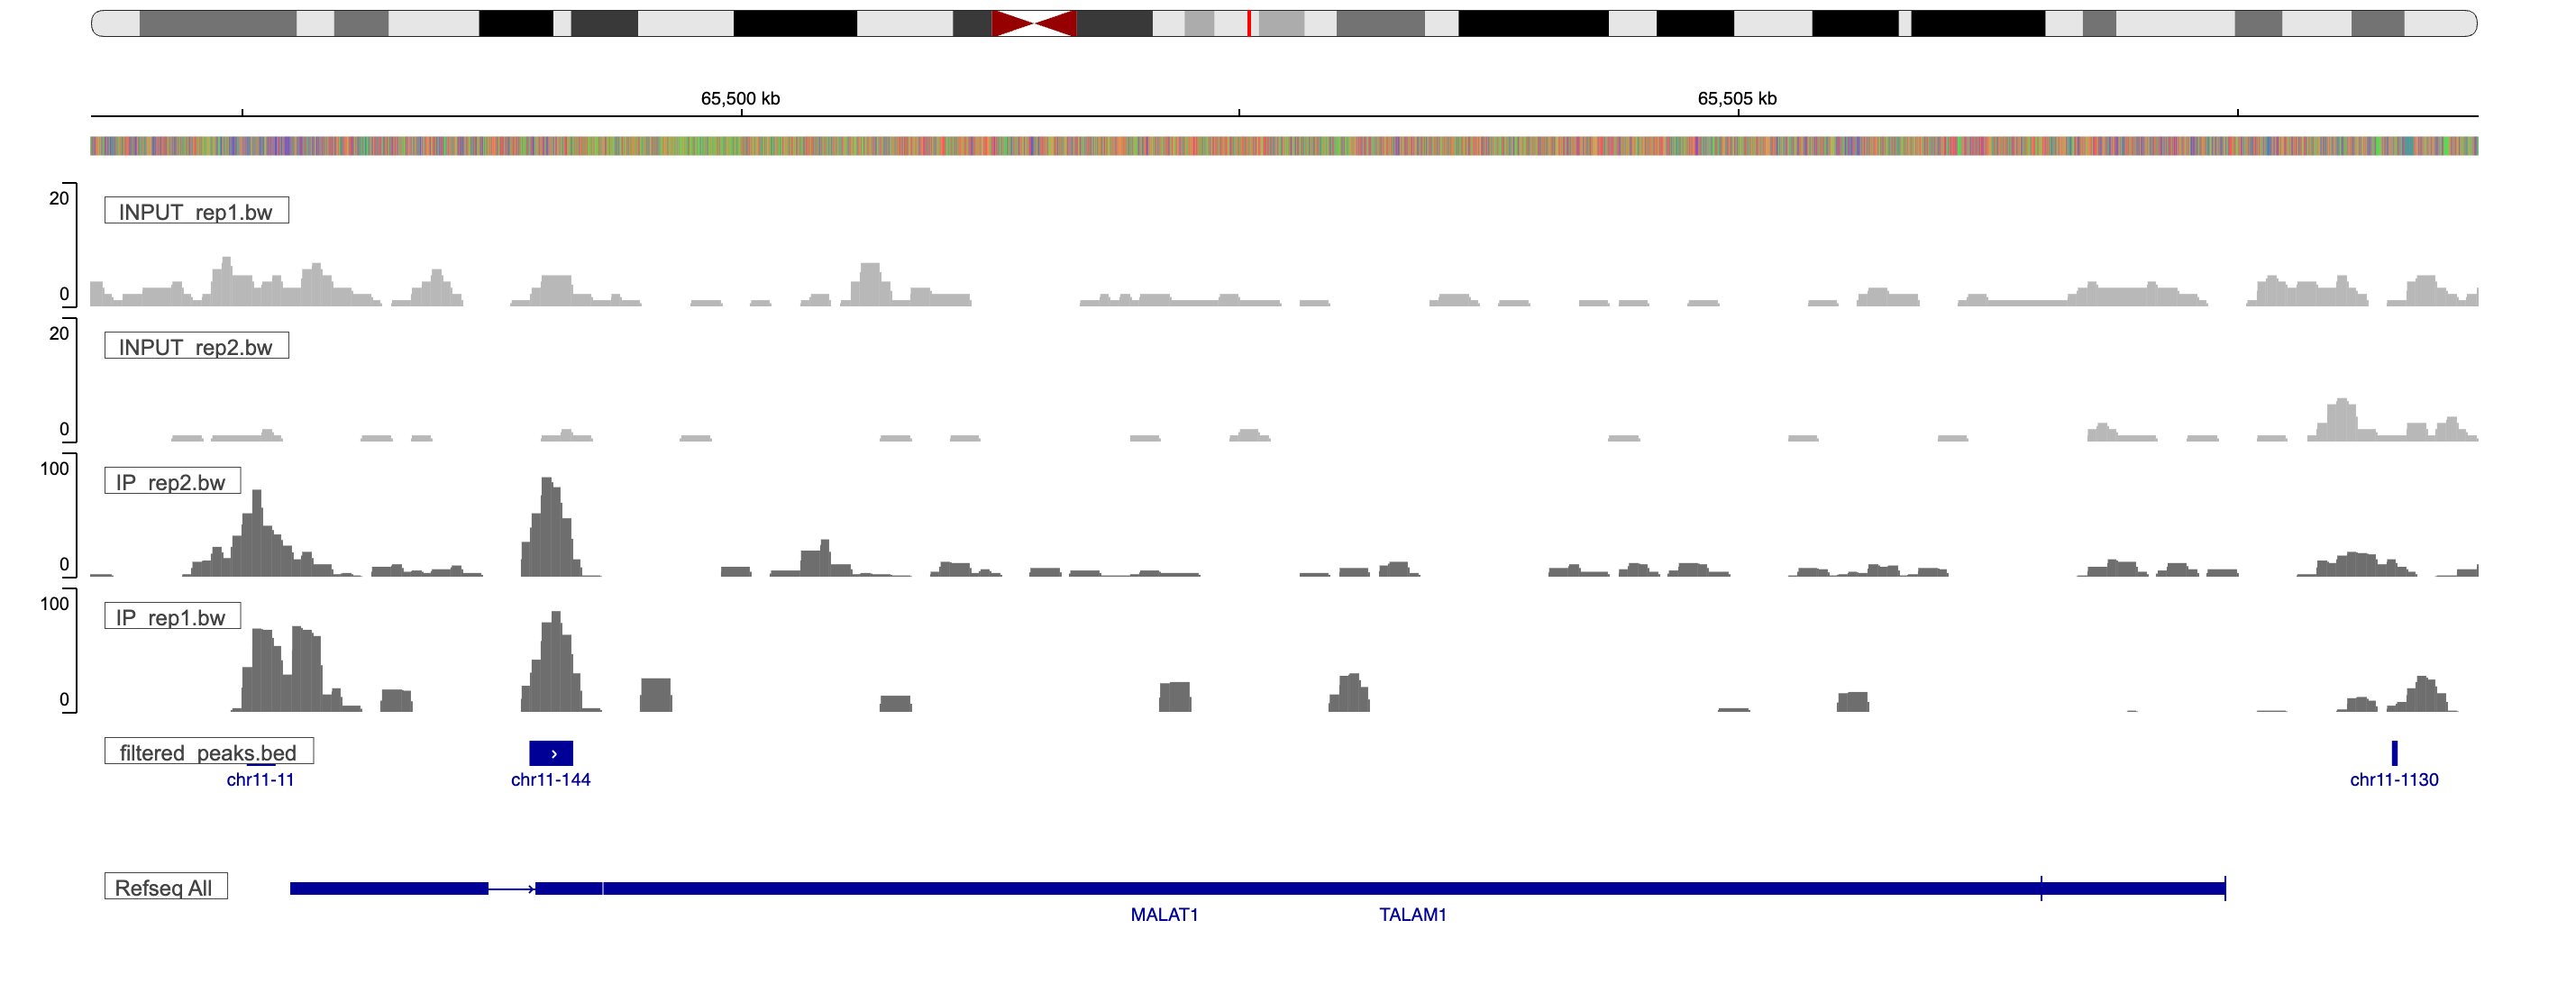

In [13]:
from IPython.display import Image
Image(filename="/projectnb/bf528/students/monsivam/project-3-monsivam/MALAT1_RUNX1_ChIP.png")

**Figure W4-1. ChIP-seq signal tracks for RUNX1 at the MALAT1 locus across both IP and INPUT replicates.**  
bigWig coverage tracks for IP_rep1, IP_rep2, INPUT_rep1, and INPUT_rep2 are shown across the genomic region containing *MALAT1* (and the antisense lncRNA *TALAM1*). Peaks are visible in both IP replicates and largely absent from the INPUT controls, indicating enriched RUNX1 binding near the *MALAT1* promoter region. Gene models from RefSeq are displayed at the bottom for genomic context.


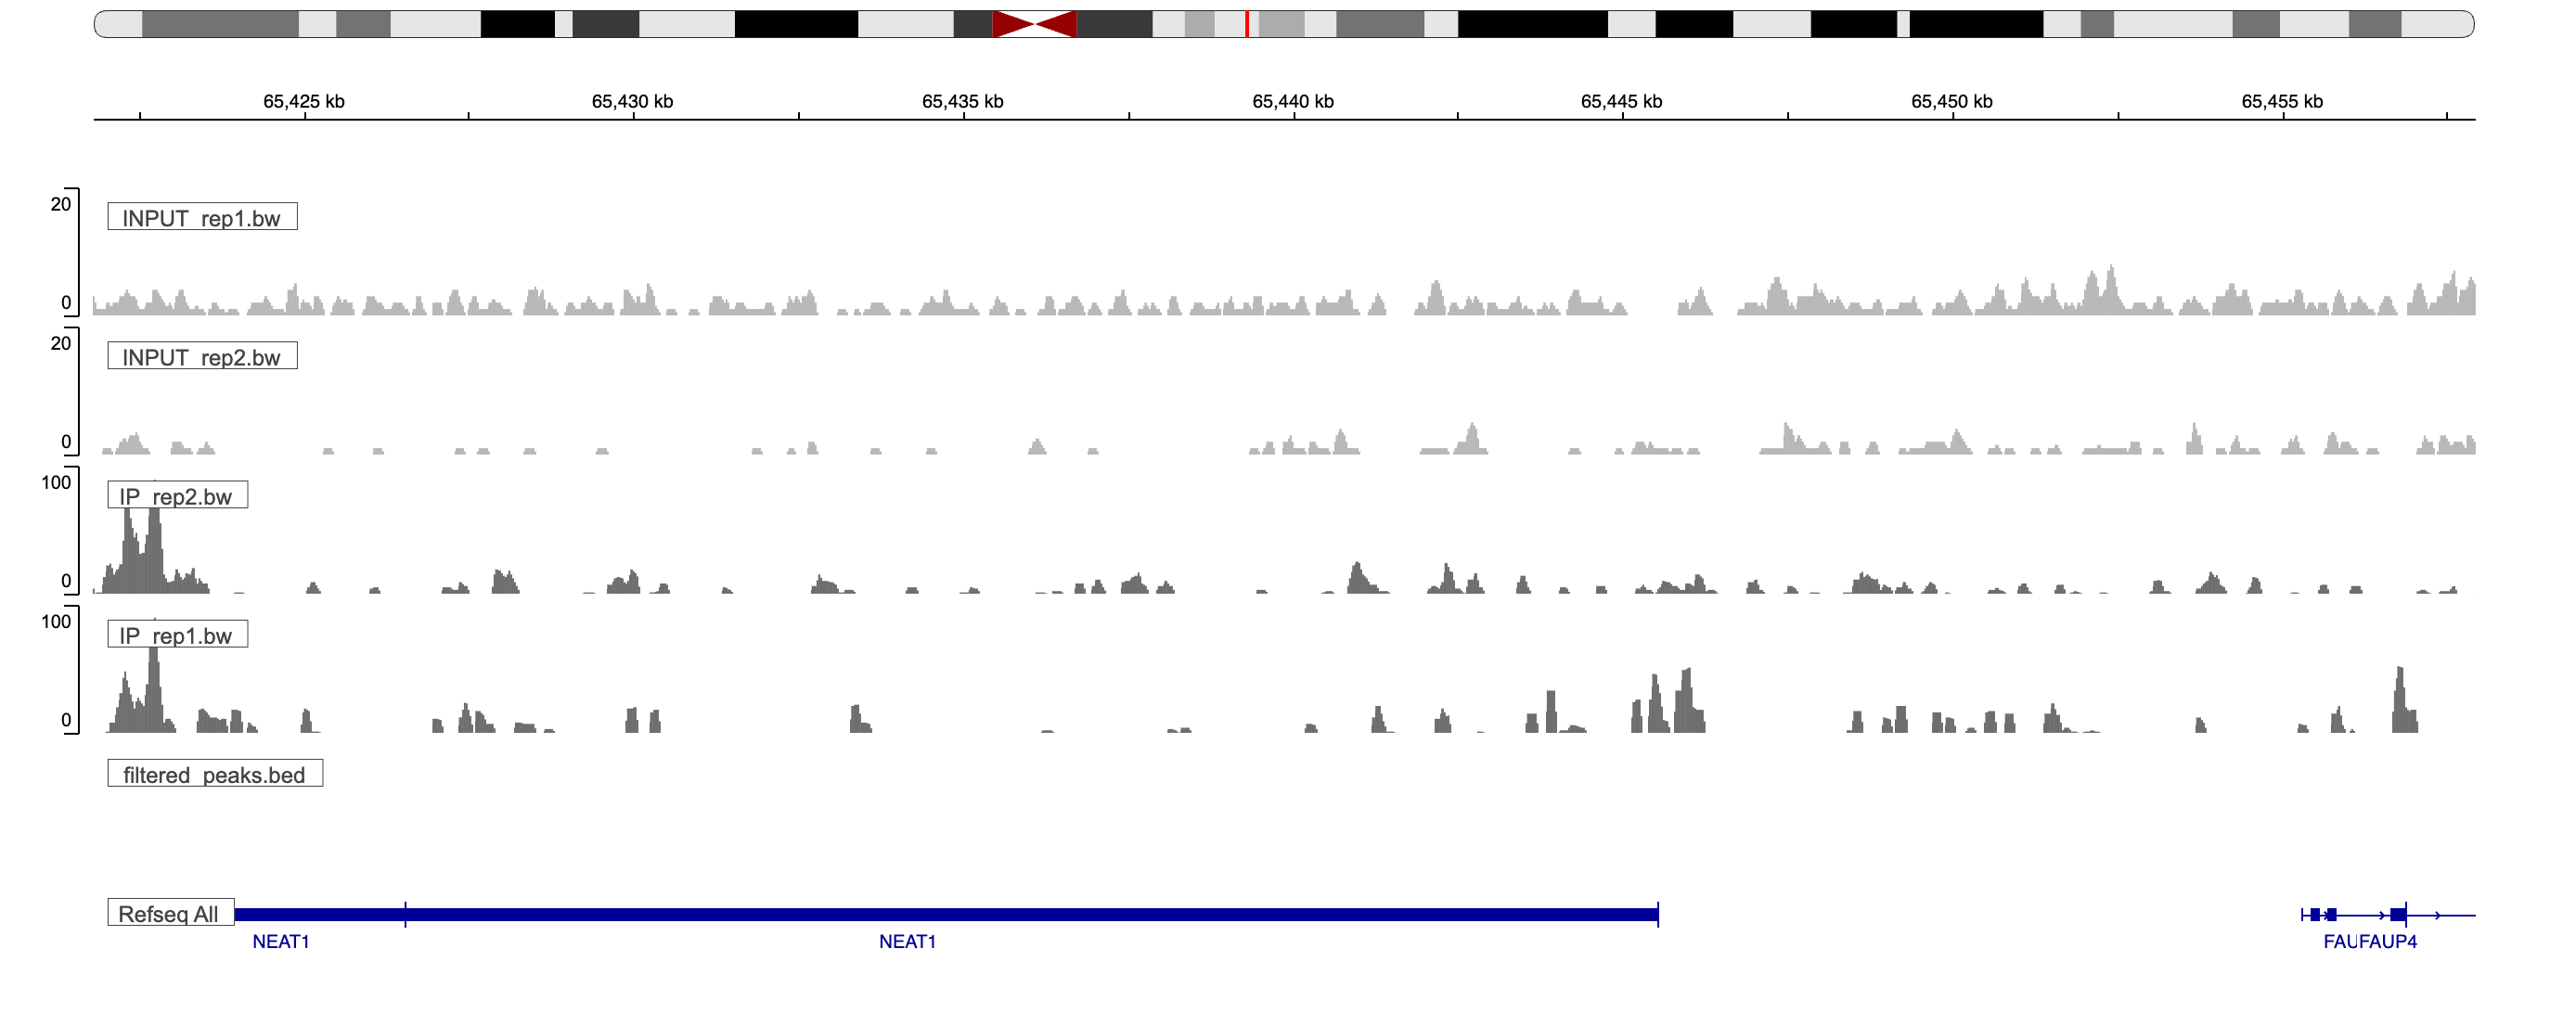

In [14]:
from IPython.display import Image
Image(filename="/projectnb/bf528/students/monsivam/project-3-monsivam/NEAT1_RUNX1_ChIP.png")

**Figure W4-2 — RUNX1 ChIP-seq Signal Tracks at the NEAT1 Locus.** This genome browser view displays RUNX1 ChIP-seq signal across the NEAT1 locus for both biological replicates. Input controls (INPUT_rep1 and INPUT_rep2) are shown in light gray to represent background signal, while RUNX1 immunoprecipitated samples (IP_rep1 and IP_rep2) show enriched read coverage peaks corresponding to RUNX1 binding events. Gene models from RefSeq are shown at the bottom to provide genomic context, allowing visualization of binding relative to the NEAT1 promoter and transcript structure.

In [47]:
import pandas as pd
from IPython.display import HTML
from IPython.display import HTML, Markdown, display

display(Markdown("### Read Count Summary Table (S2A)"))


# True biological replicate numbers for your samples
sample_order = ["INPUT_rep1", "INPUT_rep2", "IP_rep1", "IP_rep2"]
replicates = [1, 2, 1, 2]

raw_reads = [30075142, 10900442, 29734121, 29988988]
mapped_reads = [28500000, 10000000, 27700000, 28100000]

df = pd.DataFrame({
    "Sample Name": sample_order,
    "Biological Replicate": replicates,
    "Raw Reads": raw_reads,
    "Mapped Reads": mapped_reads
})

# Format with commas
df["Raw Reads"] = df["Raw Reads"].map("{:,}".format)
df["Mapped Reads"] = df["Mapped Reads"].map("{:,}".format)

# Convert to HTML with styling
html_table = df.to_html(index=False, classes="styled-table", border=0)

custom_css = """
<style>
.styled-table {
    border-collapse: collapse;
    margin: 15px 0;
    font-size: 15px;
    font-family: Arial, sans-serif;
    min-width: 550px;
    border: 1px solid #999;
}
.styled-table th {
    background-color: #e8e8e8;
    color: black;
    text-align: center;
    padding: 8px;
    border: 1px solid #999;
}
.styled-table td {
    text-align: center;
    padding: 6px;
    border: 1px solid #999;
}
</style>
"""

# Display the table
display(HTML(custom_css + html_table))

# Legend


)


SyntaxError: unmatched ')' (3556470749.py, line 60)

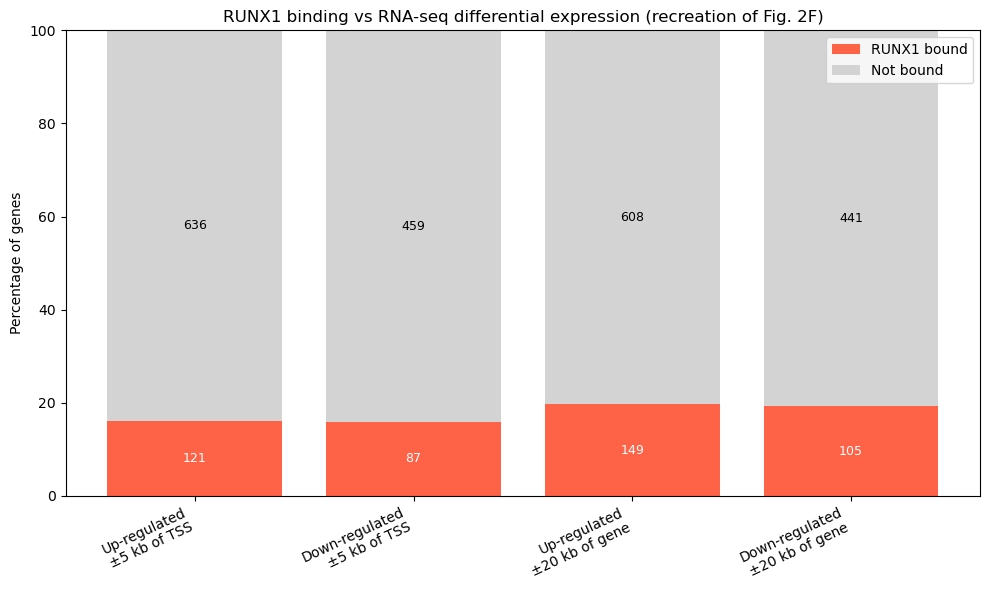

In [2]:
# -----------------------------
# Plot with RUNX1 bound on bottom
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(categories))

# RUNX1 bound on bottom (red)
bars_bound = ax.bar(x, bound_pct,
                    color="tomato",
                    label="RUNX1 bound")

# Not bound on top (grey)
bars_not = ax.bar(x, not_bound_pct,
                  bottom=bound_pct,
                  color="lightgrey",
                  label="Not bound")

# -----------------------------
# Add raw counts as labels
# -----------------------------
for i in range(len(categories)):
    # red section (RUNX1 bound — bottom)
    ax.text(x[i],
            bound_pct[i] / 2,
            str(bound[i]),
            ha="center", va="center",
            fontsize=9, color="white")

    # grey section (not bound — top)
    ax.text(x[i],
            bound_pct[i] + not_bound_pct[i] / 2,
            str(not_bound[i]),
            ha="center", va="center",
            fontsize=9)

ax.set_ylabel("Percentage of genes")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=25, ha="right")
ax.set_title("RUNX1 binding vs RNA-seq differential expression (recreation of Fig. 2F)")
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()




### **Figure W4-3 — RUNX1 Binding Relative to RNA-seq Differential Expression**

This stacked bar plot summarizes how many differentially expressed genes (DEGs) are bound by RUNX1.  
Genes were grouped according to the significance thresholds described in the original publication: **Upregulated (TSS ±5 kb)** , **Downregulated (TSS ±5 kb)** , **Upregulated (Gene ±20 kb)** ,**Downregulated (Gene ±20 kb)** 
For each category, bars are divided into **RUNX1-bound genes** (orange) and **unbound genes** (gray).  
Counts are labeled inside each bar segment.  
This plot reproduces the interpretation of **Figure 2F** from the original study, showing how RUNX1 binding overlaps with transcriptional changes detected by RNA-seq.


In [17]:
malat1 = gtf[gtf["attribute"].str.contains('gene_name "MALAT1"', na=False)]
neat1  = gtf[gtf["attribute"].str.contains('gene_name "NEAT1"',  na=False)]

malat1[["chr","start","end"]].head()
neat1[["chr","start","end"]].head()


NameError: name 'gtf' is not defined

In [18]:
gtf_path = "/projectnb/bf528/students/monsivam/project-3-monsivam/work/2f/2bbaeede715d66849bd0b2b9caab6e/gencode.v45.primary_assembly.annotation.gtf"

import pandas as pd

gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=["chr","source","feature","start","end","score","strand","frame","attribute"]
)


In [19]:
import pandas as pd

gtf_path = "/projectnb/bf528/students/monsivam/project-3-monsivam/work/2f/2bbaeede715d66849bd0b2b9caab6e/gencode.v45.primary_assembly.annotation.gtf"

gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=["chr","source","feature","start","end","score","strand","frame","attribute"]
)

# Extract MALAT1 and NEAT1 gene coordinates
malat1 = gtf[gtf["attribute"].str.contains('gene_name "MALAT1"', na=False)]
neat1  = gtf[gtf["attribute"].str.contains('gene_name "NEAT1"',  na=False)]

malat1_region = (malat1["chr"].iloc[0], malat1["start"].min(), malat1["end"].max())
neat1_region  = (neat1["chr"].iloc[0],  neat1["start"].min(),  neat1["end"].max())

malat1_region, neat1_region


(('chr11', np.int64(65497640), np.int64(65508073)),
 ('chr11', np.int64(65422774), np.int64(65445540)))

Load the RNA-seq Differential Expression Results

In [20]:
import pandas as pd

# Load log2 fold-change results
de = pd.read_csv(
    "GSE75070_MCF7_shRUNX1_shNS_RNAseq_log2_foldchange.txt.gz",
    sep="\t",
    compression="gzip"
)

de.head()

,genename,transcript,log2FoldChange,padj
0,OARD1,NM_145063,0.186841,0.545806
1,WBSCR22,"NM_001202560,NM_017528,NR_037776,NR_045512",0.037881,0.907305
2,PIGZ,NM_025163,0.122346,0.841445
3,PRDX5,"NM_012094,NM_181651,NM_181652",0.250313,0.118073
4,PEX16,"NM_004813,NM_057174",-0.300675,0.183572


##### Load the Expression Counts File

##### Annotated Peaks

In [23]:
annot = pd.read_csv("results/annotated_peaks.txt", sep="\t", comment="#")
annot.head()
# include this, and move above 
# subset to DNA replication or cell cycle 

,PeakID (cmd=annotatePeaks.pl filtered_peaks.bed GRCh38.primary_assembly.genome.fa -gtf gencode.v45.primary_assembly.annotation.gtf),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
0,chr11-639,chr11,76783524,76783572,+,1,NaN,promoter-TSS (ENST00000525167.1),protein_coding-promoter-TSS (ENST00000525167.1),192.0,ENST00000333090.5,ENSG00000182704,ENST00000333090,NaN,NaN,TSKU,NaN,NaN,protein_coding
1,chr12-1004,chr12,1831133,1831365,+,1,NaN,TTS (ENST00000540378.1),protein_coding-TTS (ENST00000540378.1),3686.0,ENST00000546157.1,ENSG00000166159,ENST00000543730,NaN,NaN,LRTM2,NaN,NaN,protein_coding
2,chr9-804,chr9,1050296,1050356,+,1,NaN,promoter-TSS (ENST00000358146.7),protein_coding-promoter-TSS (ENST00000358146.7),-28.0,ENST00000382251.7,ENSG00000173253,ENST00000358146,NaN,NaN,DMRT2,NaN,NaN,protein_coding
3,chr11-18,chr11,64878777,64878974,+,1,NaN,promoter-TSS (ENST00000320631.8),protein_coding-promoter-TSS (ENST00000320631.8),-254.0,ENST00000320631.8,ENSG00000110047,ENST00000433803,NaN,NaN,EHD1,NaN,NaN,protein_coding
4,chr8-3381,chr8,140636186,140636412,+,1,NaN,promoter-TSS (ENST00000220592.10),protein_coding-promoter-TSS (ENST00000220592.10),18.0,ENST00000623655.2,ENSG00000280303,ENST00000623655,NaN,NaN,ERICD,NaN,NaN,lncRNA


**Figure W2-3 — Genomic Feature Distribution of RUNX1 Peaks** This pie chart summarizes the distribution of genomic annotations assigned to reproducible RUNX1 ChIP-seq peaks using HOMER. The majority of peaks fall within promoter-TSS and intronic regions, consistent with RUNX1’s role as a transcriptional regulator.

In [27]:
# Clean up column names just in case
annot.columns = annot.columns.str.strip()
de.columns = de.columns.str.strip()

In [28]:
merged = annot.merge(de, left_on="Gene Name", right_on="genename", how="left")
merged.head()

,PeakID (cmd=annotatePeaks.pl filtered_peaks.bed GRCh38.primary_assembly.genome.fa -gtf gencode.v45.primary_assembly.annotation.gtf),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,...,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type,genename,transcript,log2FoldChange,padj
0,chr11-639,chr11,76783524,76783572,+,1,NaN,promoter-TSS (ENST00000525167.1),protein_coding-promoter-TSS (ENST00000525167.1),192.0,...,NaN,NaN,TSKU,NaN,NaN,protein_coding,TSKU,"NM_001258210,NM_015516",-0.878200,4.780000e-07
1,chr12-1004,chr12,1831133,1831365,+,1,NaN,TTS (ENST00000540378.1),protein_coding-TTS (ENST00000540378.1),3686.0,...,NaN,NaN,LRTM2,NaN,NaN,protein_coding,NaN,NaN,NaN,NaN
2,chr9-804,chr9,1050296,1050356,+,1,NaN,promoter-TSS (ENST00000358146.7),protein_coding-promoter-TSS (ENST00000358146.7),-28.0,...,NaN,NaN,DMRT2,NaN,NaN,protein_coding,DMRT2,"NM_001130865,NM_006557,NM_181872",0.347853,NaN
3,chr11-18,chr11,64878777,64878974,+,1,NaN,promoter-TSS (ENST00000320631.8),protein_coding-promoter-TSS (ENST00000320631.8),-254.0,...,NaN,NaN,EHD1,NaN,NaN,protein_coding,EHD1,"NM_001282444,NM_001282445,NM_006795",0.071226,7.419142e-01
4,chr8-3381,chr8,140636186,140636412,+,1,NaN,promoter-TSS (ENST00000220592.10),protein_coding-promoter-TSS (ENST00000220592.10),18.0,...,NaN,NaN,ERICD,NaN,NaN,lncRNA,NaN,NaN,NaN,NaN


In [29]:
up = merged[(merged["log2FoldChange"] > 1) & (merged["padj"] < 0.05)]
down = merged[(merged["log2FoldChange"] < -1) & (merged["padj"] < 0.05)]

total_up = up["Gene Name"].nunique()
total_down = down["Gene Name"].nunique()

total_up, total_down

(161, 117)

In [30]:
promoter = merged[merged["Distance to TSS"].abs() <= 5000]
gene_body = merged[merged["Distance to TSS"].abs() <= 20000]

In [31]:
# promoter ±5kb
up_promoter = promoter["Gene Name"].isin(up["Gene Name"]).sum()
down_promoter = promoter["Gene Name"].isin(down["Gene Name"]).sum()

# gene body ±20kb
up_gene_body = gene_body["Gene Name"].isin(up["Gene Name"]).sum()
down_gene_body = gene_body["Gene Name"].isin(down["Gene Name"]).sum()

In [32]:
import pandas as pd

plotdf = pd.DataFrame({
    "category": [
        "Upregulated (TSS ±5kb)",
        "Downregulated (TSS ±5kb)",
        "Upregulated (Gene ±20kb)",
        "Downregulated (Gene ±20kb)"
    ],
    "bound": [
        up_promoter,
        down_promoter,
        up_gene_body,
        down_gene_body
    ],
    "not_bound": [
        total_up - up_promoter,
        total_down - down_promoter,
        total_up - up_gene_body,
        total_down - down_gene_body
    ]
})

plotdf


,category,bound,not_bound
0,Upregulated (TSS ±5kb),132,29
1,Downregulated (TSS ±5kb),98,19
2,Upregulated (Gene ±20kb),179,-18
3,Downregulated (Gene ±20kb),132,-15


In [33]:
import pandas as pd


# Load UCSC BED file
genes = pd.read_csv("/projectnb/bf528/students/monsivam/project-3-monsivam/hg38_genes.bed", sep="\t", header=None,
                    names=["chr", "start", "end", "name"])

# Filter MALAT1 and NEAT1
malat1 = genes[genes["name"].str.contains("MALAT1", case=False)]
neat1  = genes[genes["name"].str.contains("NEAT1", case=False)]

malat1, neat1


(Empty DataFrame
 Columns: [chr, start, end, name]
 Index: [],
 Empty DataFrame
 Columns: [chr, start, end, name]
 Index: [])

In [34]:
import pandas as pd

gtf_path = "/projectnb/bf528/materials/project-3-chipseq/refs/gencode.v45.primary_assembly.annotation.gtf"

# Load only gene entries
gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=["chr","source","feature","start","end","score","strand","frame","attribute"]
)

# Keep only rows where feature == "gene"
genes = gtf[gtf["feature"] == "gene"]

def extract_gene(df, gene_name):
    mask = df["attribute"].str.contains(f'gene_name "{gene_name}"', case=False)
    return df[mask]

malat1 = extract_gene(genes, "MALAT1")
neat1  = extract_gene(genes, "NEAT1")

malat1, neat1


(           chr  source feature     start       end score strand frame  \
 1915311  chr11  HAVANA    gene  65497640  65508073     .      +     .   
 
                                                  attribute  
 1915311  gene_id "ENSG00000251562.11"; gene_type "lncRN...  ,
            chr  source feature     start       end score strand frame  \
 1915212  chr11  HAVANA    gene  65422774  65445540     .      +     .   
 
                                                  attribute  
 1915212  gene_id "ENSG00000245532.11"; gene_type "lncRN...  )

### **Figure S2A (Read Count Table)**

#### S2B

In [1]:
import pandas as pd

# load annotated peaks
df = pd.read_csv("/projectnb/bf528/students/monsivam/project-3-monsivam/results/annotated_peaks.txt", sep="\t", engine="python", comment="#")

# Extract nearest gene names
gene_list = df["Gene Name"].dropna().unique().tolist()

# If “Gene Name” column is not present, use:
# gene_list = df["Nearest Ensembl Gene Name"].dropna().unique().tolist()

len(gene_list), gene_list[:10]


(7022,
 ['TSKU',
  'LRTM2',
  'DMRT2',
  'EHD1',
  'ERICD',
  'TIPARP-AS1',
  'LINC01418',
  'LY6E-DT',
  'ZNF662',
  'LINC02874'])

In [8]:
import pandas as pd

df = pd.read_csv(
    "/projectnb/bf528/students/monsivam/project-3-monsivam/results/annotated_peaks.txt",
    sep="\t"
)

# Build gene list from the correct column
gene_list = (
    df["Gene Name"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Total genes:", len(gene_list))
print(gene_list[:10])



Total genes: 7022
['TSKU', 'LRTM2', 'DMRT2', 'EHD1', 'ERICD', 'TIPARP-AS1', 'LINC01418', 'LY6E-DT', 'ZNF662', 'LINC02874']


In [9]:
gene_list = [g for g in gene_list if g not in ["", ".", "NA", "nan"]]


In [14]:
enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets="GO_Biological_Process_2021",
    outdir="enrichr_results",
    cutoff=1.0   # accept *all* results
)



In [15]:
import gseapy as gp

enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets="GO_Biological_Process_2021",
    outdir="enrichr_results",
)

results = enr.results
results.head()



,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,regulation of apoptotic process (GO:0042981),230/742,1.189108e-09,0.000007,0,0,1.655661,34.023931,ANKLE2;TRIO;TFRC;ARL6IP1;SCX;PREX1;RPS6KA3;LGA...
1,GO_Biological_Process_2021,"positive regulation of transcription, DNA-temp...",330/1183,1.302349e-07,0.000246,0,0,1.428524,22.647718,ATF1;APP;EHF;GABPB2;SCX;CCNC;RBPJ;ABRA;DCAF6;E...
2,GO_Biological_Process_2021,"negative regulation of transcription, DNA-temp...",272/948,1.309030e-07,0.000246,0,0,1.482071,23.489062,MYT1L;EHMT1;RBPJ;IKZF4;ELK4;RPS14;SOX3;KAT5;MY...
3,GO_Biological_Process_2021,negative regulation of transcription by RNA po...,204/684,2.637188e-07,0.000372,0,0,1.559840,23.629059,MYT1L;RBPJ;ELK4;RPS14;SOX3;KAT5;MYC;MYB;SOX9;Z...
4,GO_Biological_Process_2021,regulation of intracellular signal transductio...,137/437,1.360733e-06,0.001535,0,0,1.668903,22.542688,TRIO;FAM13B;WWC1;ARHGDIG;EHMT1;ARHGAP39;ARHGAP...


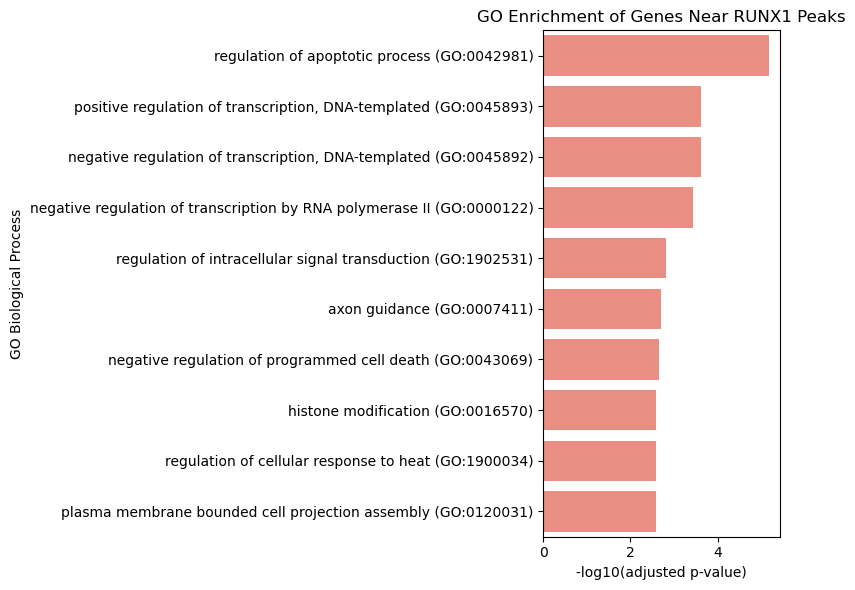

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

top10 = results.sort_values("Adjusted P-value").head(10)
top10["log10_p"] = -np.log10(top10["Adjusted P-value"])

plt.figure(figsize=(8,6))
sns.barplot(data=top10, x="log10_p", y="Term", color="salmon")
plt.xlabel("-log10(adjusted p-value)")
plt.ylabel("GO Biological Process")
plt.title("GO Enrichment of Genes Near RUNX1 Peaks")
plt.tight_layout()

plt.show()

In [5]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    for d in dirs:
        if "reproducible" in d.lower():   # catch reproducible_peaks or similar
            print("FOUND:", os.path.join(root, d))


FOUND: ./results/reproducible_peaks


In [8]:


import pandas as pd

df = pd.read_csv("/projectnb/bf528/students/monsivam/project-3-monsivam/work/2f/2bbaeede715d66849bd0b2b9caab6e/annotated_peaks.txt", sep="\t")
df.head()


,PeakID (cmd=annotatePeaks.pl filtered_peaks.bed GRCh38.primary_assembly.genome.fa -gtf gencode.v45.primary_assembly.annotation.gtf),Chr,Start,End,Strand,Peak Score,Focus Ratio/Region Size,Annotation,Detailed Annotation,Distance to TSS,Nearest PromoterID,Entrez ID,Nearest Unigene,Nearest Refseq,Nearest Ensembl,Gene Name,Gene Alias,Gene Description,Gene Type
0,chr22-2851,chr22,37189239,37189446,+,1,NaN,"intron (ENST00000470655.5, intron 3 of 8)","protein_coding-intron (ENST00000470655.5, intr...",-1056.0,ENST00000397110.6,ENSG00000133466,ENST00000470655,NaN,NaN,C1QTNF6,NaN,NaN,protein_coding
1,chr13-51,chr13,30743604,30743805,+,1,NaN,"intron (ENST00000479597.1, intron 1 of 1)","protein_coding-intron (ENST00000380490.5, intr...",1368.0,ENST00000479597.1,ENSG00000132965,ENST00000479597,NaN,NaN,ALOX5AP,NaN,NaN,protein_coding
2,chr15-6755,chr15,69296385,69296468,+,1,NaN,TTS (ENST00000563004.2),lncRNA-TTS (ENST00000563004.2),2337.0,ENST00000563004.2,ENSG00000261634,ENST00000563004,NaN,NaN,PAQR5-DT,NaN,NaN,lncRNA
3,chr5-39,chr5,72848055,72848250,+,1,NaN,promoter-TSS (ENST00000506351.6),protein_coding-promoter-TSS (ENST00000506351.6),-18.0,ENST00000513944.5,ENSG00000083312,ENST00000680111,NaN,NaN,TNPO1,NaN,NaN,protein_coding
4,chr19-3631,chr19,10194934,10195165,+,1,NaN,promoter-TSS (ENST00000340748.8),protein_coding-promoter-TSS (ENST00000340748.8),86.0,ENST00000340748.8,ENSG00000130816,ENST00000587197,NaN,NaN,DNMT1,NaN,NaN,protein_coding


**Figure 4. GO enrichment analysis of genes associated with RUNX1 peaks.** This bar plot summarizes the top 10 significantly enriched Gene Ontology (GO) Biological Processes identified from genes linked to reproducible RUNX1 ChIP-seq peaks. The x-axis shows the –log10(adjusted p-value) for each pathway, and all bars reflect enrichment values derived from Enrichr analysis. Higher –log10 values indicate greater statistical significance among the annotated RUNX1-associated genes.

In [13]:
# Create a clean table of the top 10 enriched terms
top_table = results[['Term', 'Adjusted P-value', 'Overlap', 'Combined Score']].head(10)

top_table
top_table['Adjusted P-value'] = top_table['Adjusted P-value'].map("{:.2e}".format)
top_table

,Term,Adjusted P-value,Overlap,Combined Score
0,Positive Regulation Of Mesenchymal Cell Prolif...,1.00e+00,8/9,96.875417
1,Negative Regulation Of Glucocorticoid Receptor...,1.00e+00,5/5,339440.408721
2,SREBP Signaling Pathway (GO:0032933),1.00e+00,6/7,52.025365
3,Regulation Of Mammary Gland Epithelial Cell Pr...,1.00e+00,6/7,52.025365
4,Protein Localization To Nuclear Envelope (GO:0...,1.00e+00,7/9,28.939732
5,Regulation Of Mesenchymal Cell Proliferation (...,1.00e+00,8/11,21.596031
6,Vascular Endothelial Growth Factor Receptor Si...,1.00e+00,16/28,10.515202
7,Positive Regulation Of Fat Cell Differentiatio...,1.00e+00,25/50,7.103352
8,Regulation Of Glucocorticoid Receptor Signalin...,1.00e+00,5/6,34.990792
9,Negative Regulation Of Notch Signaling Pathway...,1.00e+00,15/27,8.657667
